In [16]:
import numpy as np
import torch 
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

In [17]:
from data import get_physics_dataset, UnifiedDatasetWrapper


def form_dataset(train: bool = False) -> torch.utils.data.Dataset:
    data_filepath = 'data_demo/caloGAN_case11_5D_120K.npz'
    return UnifiedDatasetWrapper(get_physics_dataset(data_filepath, train=train))

data = form_dataset(train=True)
val_data = form_dataset(train=False)
dl = torch.utils.data.DataLoader(data, batch_size=32)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=32)

In [18]:
for i in val_loader:
    energy = i[0]
    point = i[1][0]
    momentum = i[1][1]
    print(i[0].shape)
    print(i[1][0].shape)
    print(i[1][1].shape)
    break

torch.Size([32, 1, 30, 30])
torch.Size([32, 2])
torch.Size([32, 3])


In [19]:
ticks = list(range(-20, 20 + 1, 5))
ticks

[-20, -15, -10, -5, 0, 5, 10, 15, 20]

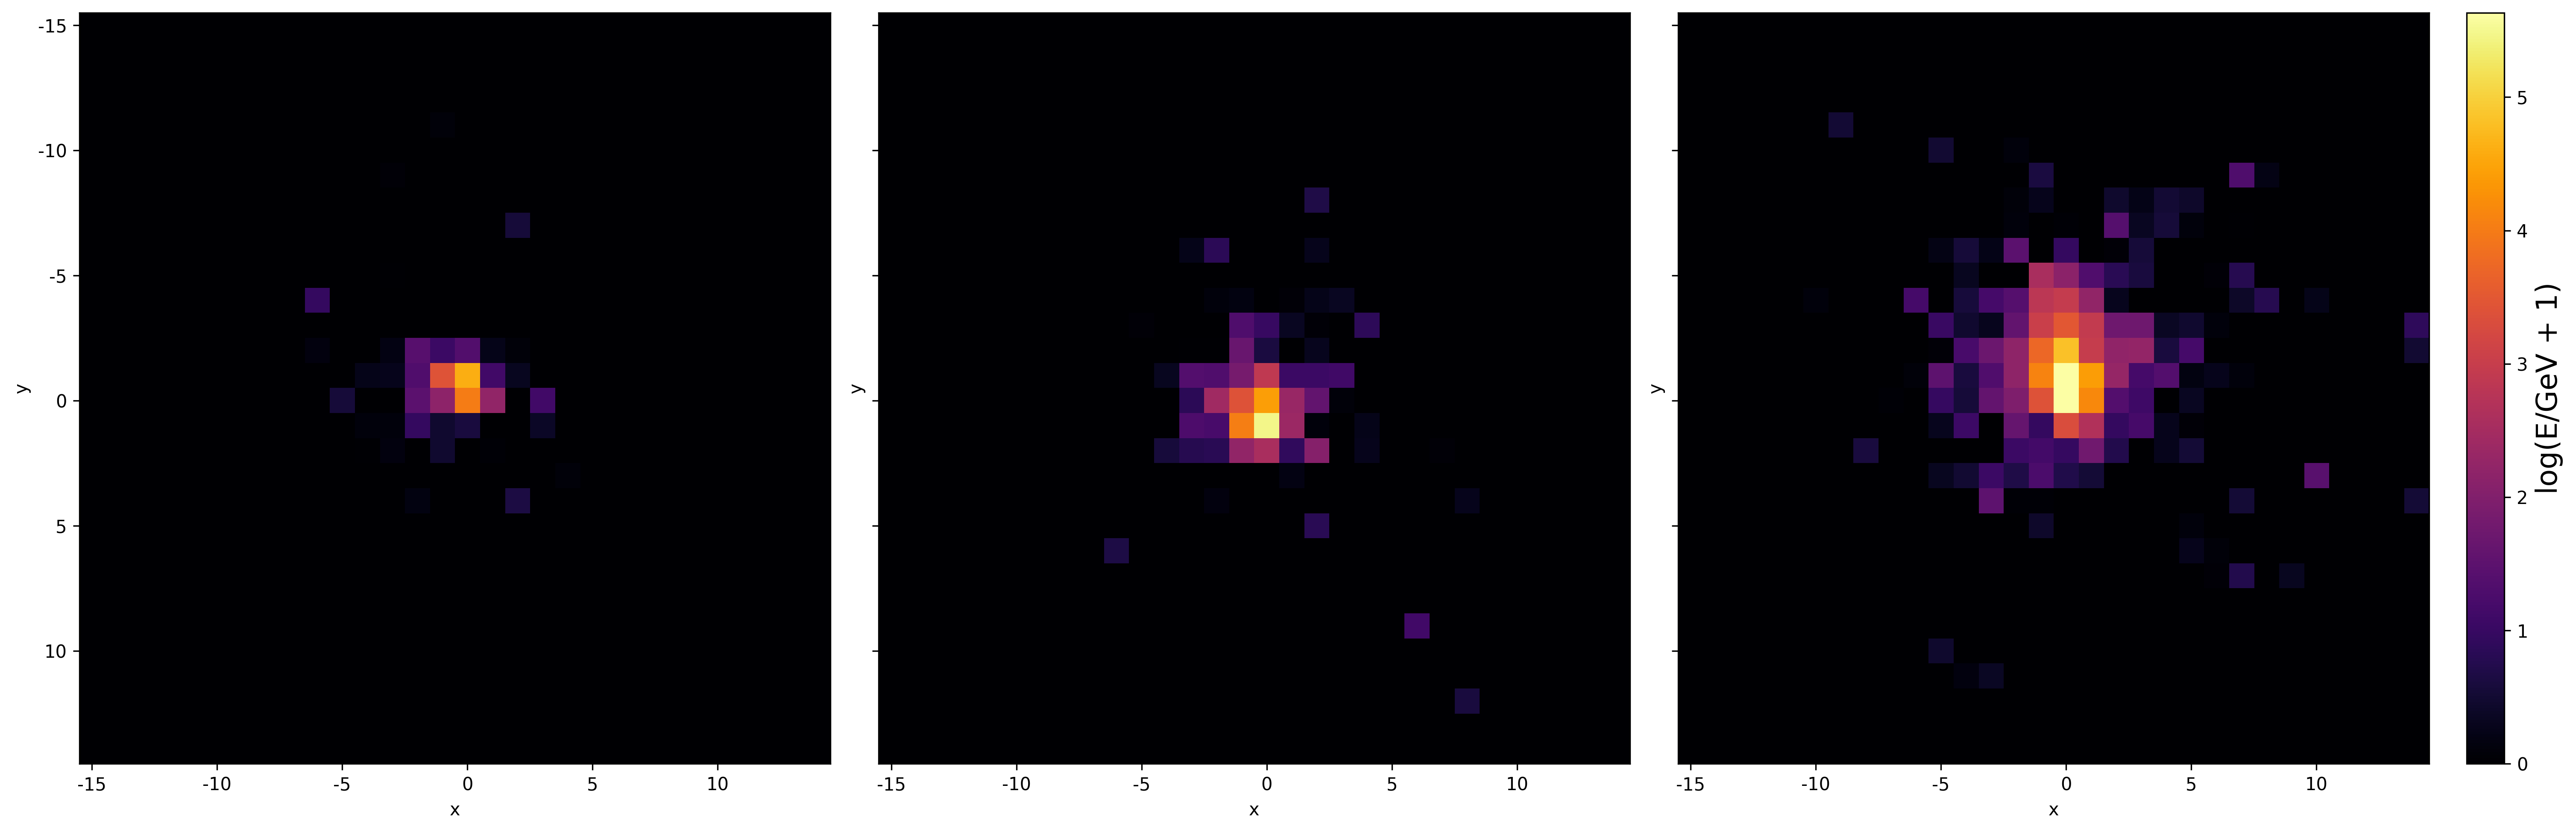

In [20]:
fig, axs = plt.subplots(1, 3, layout='constrained', sharex=True, sharey=True, dpi=300, figsize=(20, 14))
vmin, vmax = min(energy[0].min(), energy[1].min(), energy[2].min()), max(energy[0].max(), energy[1].max(), energy[2].max())
for i, k in enumerate([1, 3, 5]):
    im = axs[i].imshow(np.transpose(energy[k], (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    axs[i].set_yticklabels(ticks)
    axs[i].set_xticklabels(ticks)
    axs[i].set_ylabel('y')
    axs[i].set_xlabel('x')
cbar = fig.colorbar(im, fraction=0.05)
cbar.set_label('log(E/GeV + 1)', size=16)
plt.show()
fig.savefig('/Users/sasaatlasov/Desktop/DiffusionDipolma/real.pdf', bbox_inches = "tight")

In [21]:
from diffusion import DiffusionModel

dm = DiffusionModel(100, 16)
dm.load_state_dict(torch.load('checkpoints/t100_cos.pt', map_location=torch.device('cpu')))
dm.eval();

In [22]:
# from torchview import draw_graph

# model_graph = draw_graph(dm, input_data=(energy, momentum, point), save_graph=True, filename='model')
# model_graph.visual_graph

In [23]:
# from torchsummary import summary

# summary(model, [(1, 30, 30), [3], [2], [1]])

In [24]:
with torch.no_grad():
    samples = dm.sample(momentum, point)

  0%|          | 0/99 [00:00<?, ?it/s]

In [25]:
def compare(energy, samples, idx=0, truncate=None):
    real, sampled = energy[idx].detach().numpy(), samples[idx].detach().numpy()
    vmin, vmax = min(real.min(), sampled.min()), max(real.max(), sampled.max())
    if truncate:
        sampled = np.where(sampled >= np.log1p(truncate), sampled, np.zeros_like(samples))
    fig, axs = plt.subplots(1, 2, layout='constrained', sharex=True, sharey=True)
    sum1, sum2 = energy[idx].sum(), samples[idx].sum()
    im1 = axs[0].imshow(np.transpose(real, (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    axs[0].set(title=f'real {sum1:.2f}')
    im2 = axs[1].imshow(np.transpose(sampled, (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    axs[1].set(title=f'generated {sum2:.2f}')
    fig.colorbar(im2, fraction=0.05)
    plt.show()

In [26]:
def commm(idx=0):
    #s = np.where(samples[idx] >= np.log1p(5e-3), samples[idx], torch.zeros_like(samples[idx]))
    s = np.ma.masked_less(samples[idx], np.log1p(5e-3))
    r = np.ma.masked_less(energy[idx], np.log1p(5e-3))
    fig, axs = plt.subplots(1, 2, layout='constrained', sharex=True, sharey=True)
    im1 = axs[0].imshow(np.transpose(r, (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    im2 = axs[1].imshow(np.transpose(s, (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    fig.colorbar(im2, fraction=0.05)
    plt.show()
    s = torch.tensor(s)
    print('Non-zero', (energy[idx] > 0).sum().item(), (s > 0).sum().item())
    print('Common', ((energy[idx] > 0) * (s > 0)).sum().item())
    print('Min', energy[idx][energy[idx] > 0].min().item(), s[s > 0].min().item())
    print('Max', energy[idx][energy[idx] > 0].max().item(), s[s > 0].max().item())
    print('Sum', energy[idx][energy[idx] > 0].sum().item(), s[s > 0].sum().item())
    print('Mean', energy[idx][energy[idx] > 0].mean().item(), s[s > 0].mean().item())
    return

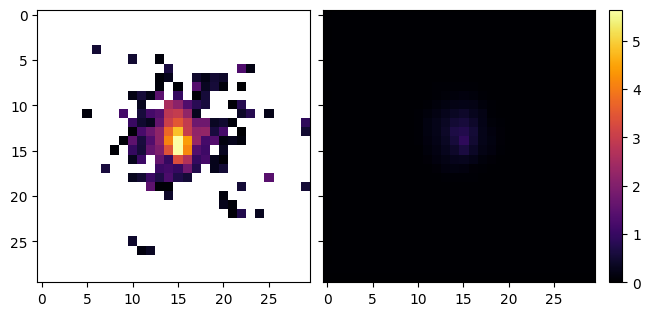

Non-zero 153 900
Common 153
Min 2.653067383562302e-07 0.0067519862204790115
Max 6.401881217956543 0.888093113899231
Sum 156.08648681640625 44.583335876464844
Mean 1.0201730728149414 0.049537040293216705


In [27]:
commm(5)

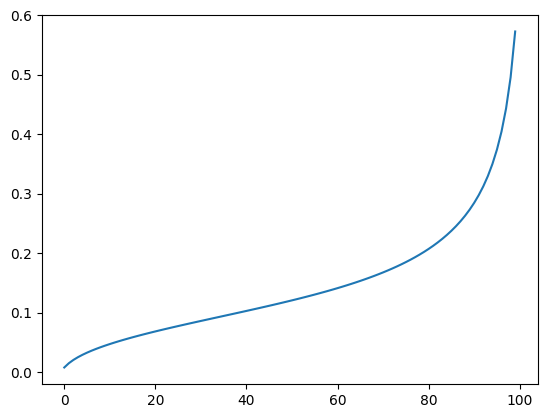

In [32]:
sigmas = (dm.sqrt_betas ** 2)[:-1] * (1 - dm.alphas_cumprod[:-1]) / (1 - dm.alphas_cumprod[1:])
plt.plot(torch.sqrt(sigmas))

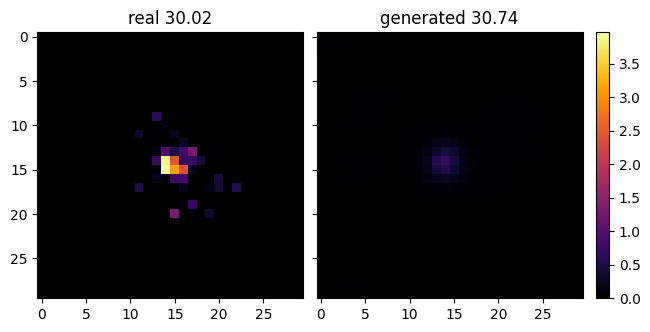

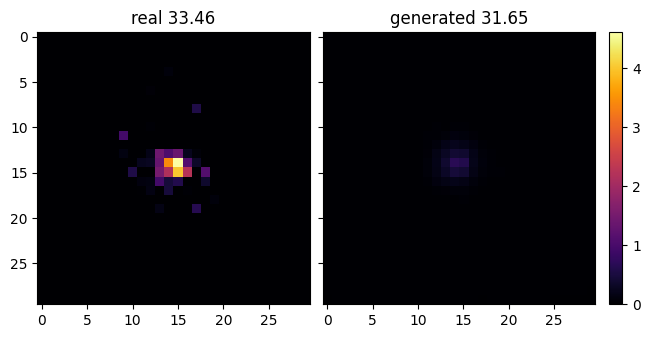

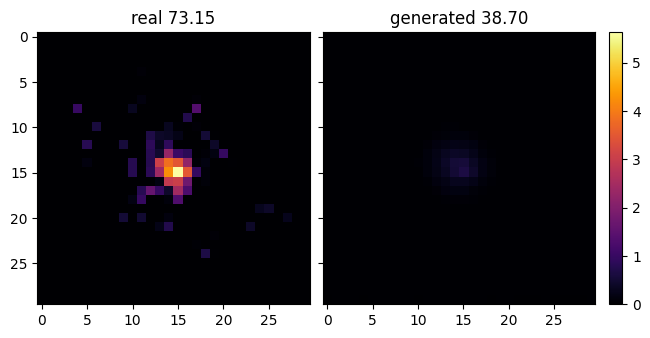

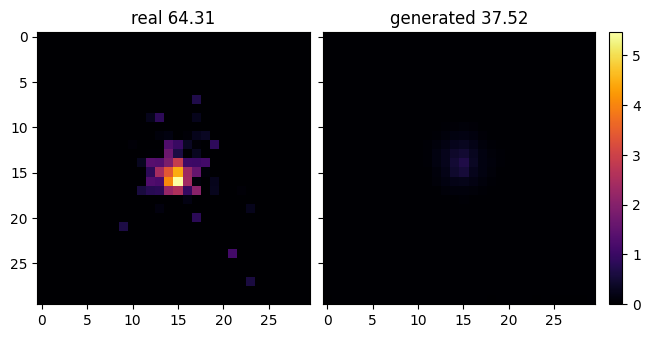

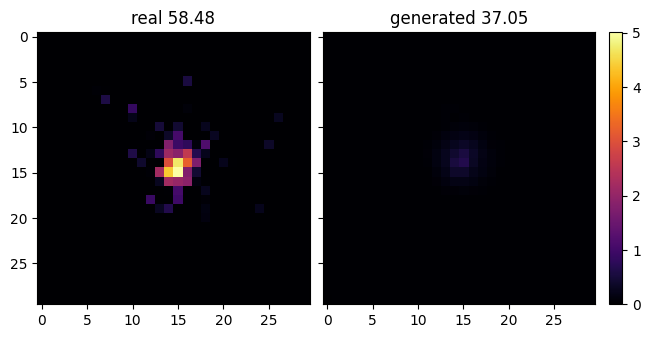

In [28]:
t = np.log1p(0)
for i in range(5):
    compare(energy, samples, idx=i)

In [29]:
def timestep_to_alpha(timesteps, T):
    return np.cos((timesteps / T + 0.008) * np.pi / ((1 + 0.008) * 2))

def get_cosine_schedules(num_timesteps: int):

    alphas_cumprod = torch.tensor(timestep_to_alpha(np.arange(0, num_timesteps + 1), num_timesteps + 1))
    betas = torch.tensor(1 - alphas_cumprod[1:] / alphas_cumprod[:-1])
    alphas_cumprod = alphas_cumprod[:-1]
    sqrt_betas = torch.sqrt(betas)
    alphas = 1 - betas
    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
    inv_sqrt_alphas = 1 / torch.sqrt(alphas)
    sqrt_one_minus_alpha_prod = torch.sqrt(1 - alphas_cumprod)
    one_minus_alpha_over_prod = (1 - alphas) / sqrt_one_minus_alpha_prod

    return {
        "alphas": alphas,
        "inv_sqrt_alphas": inv_sqrt_alphas,
        "sqrt_betas": sqrt_betas,
        "alphas_cumprod": alphas_cumprod,
        "sqrt_alphas_cumprod": sqrt_alphas_cumprod,
        "sqrt_one_minus_alpha_prod": sqrt_one_minus_alpha_prod,
        "one_minus_alpha_over_prod": one_minus_alpha_over_prod,
    }

In [30]:
get_cosine_schedules(500)

{'alphas': tensor([1.0000, 0.9999, 0.9999, 0.9999, 0.9999, 0.9999, 0.9999, 0.9999, 0.9999,
         0.9999, 0.9999, 0.9998, 0.9998, 0.9998, 0.9998, 0.9998, 0.9998, 0.9998,
         0.9998, 0.9998, 0.9998, 0.9998, 0.9997, 0.9997, 0.9997, 0.9997, 0.9997,
         0.9997, 0.9997, 0.9997, 0.9997, 0.9997, 0.9996, 0.9996, 0.9996, 0.9996,
         0.9996, 0.9996, 0.9996, 0.9996, 0.9996, 0.9996, 0.9995, 0.9995, 0.9995,
         0.9995, 0.9995, 0.9995, 0.9995, 0.9995, 0.9995, 0.9995, 0.9994, 0.9994,
         0.9994, 0.9994, 0.9994, 0.9994, 0.9994, 0.9994, 0.9994, 0.9994, 0.9993,
         0.9993, 0.9993, 0.9993, 0.9993, 0.9993, 0.9993, 0.9993, 0.9993, 0.9993,
         0.9992, 0.9992, 0.9992, 0.9992, 0.9992, 0.9992, 0.9992, 0.9992, 0.9992,
         0.9992, 0.9991, 0.9991, 0.9991, 0.9991, 0.9991, 0.9991, 0.9991, 0.9991,
         0.9991, 0.9990, 0.9990, 0.9990, 0.9990, 0.9990, 0.9990, 0.9990, 0.9990,
         0.9990, 0.9990, 0.9989, 0.9989, 0.9989, 0.9989, 0.9989, 0.9989, 0.9989,
         0.9989, 0